# Task 3: Correlation Between News Sentiment and Stock Movements

**Objective:**  
Align news headlines with stock prices, compute sentiment scores, calculate daily stock returns, and analyze correlations.

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd

In [2]:
import sys
import os

# Add project root (one directory above "notebooks")
sys.path.append(os.path.abspath(".."))

In [3]:
from scripts.load_data import load_and_prepare_full_stocks, load_and_prepare_news, align_news_with_stocks
from scripts.sentiment_analysis import add_sentiment_scores, aggregate_daily_sentiment
from scripts.correlation import merge_sentiment_and_returns, compute_correlations
from scripts.visualization import plot_sentiment_vs_return, plot_sentiment_distribution


In [4]:
# Load and prepare both datas
stocks = load_and_prepare_full_stocks( "../data/processed/stocks_full.csv")
news = load_and_prepare_news( "../data/processed/raw_analyst_ratings_clean.csv")

In [5]:
# Align datasets
news = align_news_with_stocks(news, stocks)

# Quick Check
print(stocks.dtypes)
print(news.dtypes)
news.head()

Aligned news: 4,624 rows (from 1,407,328)
Date            datetime64[ns]
Ticker                  object
Close                  float64
Daily_Return           float64
dtype: object
Date        datetime64[ns]
headline            object
stock               object
dtype: object


,Date,headline,stock
7159,2020-06-02,'Apple is tracking iPhones stolen by looters' ...,AAPL
7160,2020-06-02,MoneyGram Shares Jump 50% As Western Union Rep...,AAPL
7161,2020-06-02,Hearing Susquehanna Check Suggests Total iPhon...,AAPL
7162,2020-06-02,Tesla CEO Musk Says Other Three Officers Shoul...,AAPL
7163,2020-06-02,A Peek Into The Markets: US Stock Futures Up; ...,AAPL


## 2. Sentiment Analysis

In [6]:
news = add_sentiment_scores(news)

# Aggregate daily sentiment per stock
daily_sentiment = aggregate_daily_sentiment(news)

# Quick Check
daily_sentiment.head()

,Date,stock,avg_sentiment
0,2011-03-03,NVDA,-0.300
1,2011-03-07,NVDA,-0.125
2,2011-03-08,NVDA,0.000
3,2011-03-09,NVDA,0.000
4,2011-03-10,NVDA,0.500


## 3. Merge News and Stock Data

In [7]:
# merge the daily_sentiment  and stocks data frames for further analysis
merged = merge_sentiment_and_returns(daily_sentiment, stocks)

# save merged data for the future
merged.to_csv("../data/processed/news_stock_merged.csv", index=False)

# Quick check
print(merged.shape)
merged.head()

Merged dataset: 1,527 matched day-stock pairs
(1527, 4)


,Date,stock,avg_sentiment,Daily_Return
0,2011-03-03,NVDA,-0.300,0.005783
1,2011-03-07,NVDA,-0.125,-0.013969
2,2011-03-08,NVDA,0.000,-0.044944
3,2011-03-09,NVDA,0.000,-0.020972
4,2011-03-10,NVDA,0.500,-0.063741


## 4. Correlation Analysis

In [8]:
correlations = compute_correlations(merged)
print("\nCorrelation Results:")
print("-" * 40)
for name, value in correlations.items():
    if value is not None:
        print(f"{name.replace('_', ' ').title():25}: {value:.4f}")


Correlation Results:
----------------------------------------
Pearson Same Day         : 0.0992
Spearman Same Day        : 0.1266
Pearson Next Day         : -0.0167


## 5. Visualizations

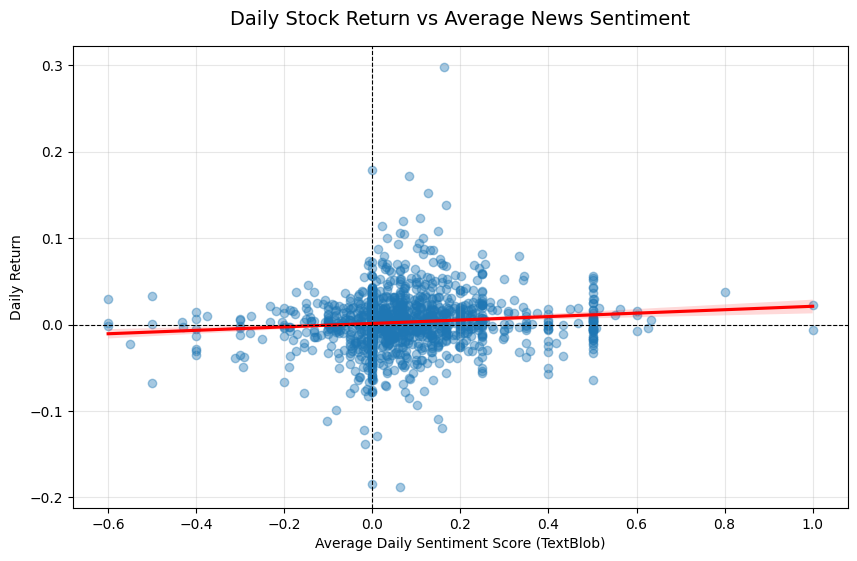

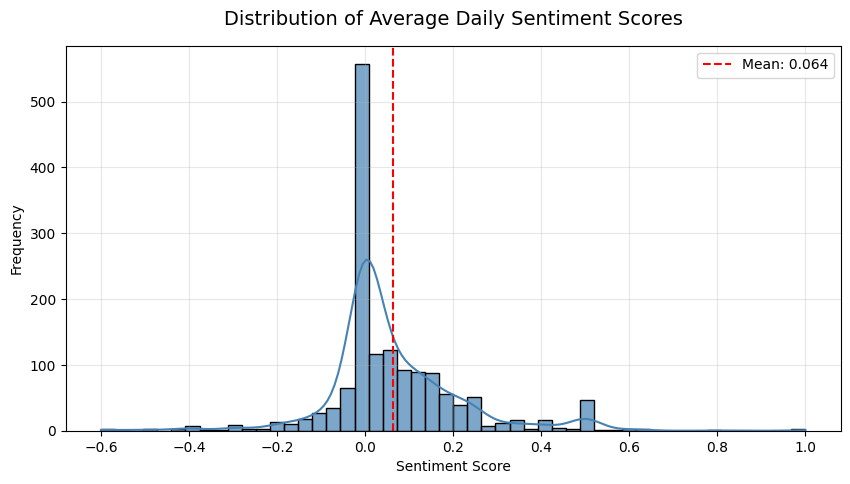

In [9]:
# Scatter plot with regression line
plot_sentiment_vs_return(merged)

# Distribution of sentiment scores    
plot_sentiment_distribution(merged)